In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
url = "https://stats.idre.ucla.edu/stat/stata/dae/binary.dta"

df = pd.read_stata(url)
# stata is used to read binary data
df.head()

,admit,gre,gpa,rank
0,0.0,380.0,3.61,3.0
1,1.0,660.0,3.67,3.0
2,1.0,800.0,4.00,1.0
3,1.0,640.0,3.19,4.0
4,0.0,520.0,2.93,4.0


In [4]:
print(df.shape)

(400, 4)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   admit   400 non-null    float32
 1   gre     400 non-null    float32
 2   gpa     400 non-null    float32
 3   rank    400 non-null    float32
dtypes: float32(4)
memory usage: 6.4 KB


In [6]:
df.describe()

,admit,gre,gpa,rank
count,400.000000,400.000000,400.000000,400.000000
mean,0.317500,587.700012,3.389900,2.485000
std,0.466087,115.516663,0.380567,0.944462
min,0.000000,220.000000,2.260000,1.000000
25%,0.000000,520.000000,3.130000,2.000000
50%,0.000000,580.000000,3.395000,2.000000
75%,1.000000,660.000000,3.670000,3.000000
max,1.000000,800.000000,4.000000,4.000000


In [7]:
df['admit'].value_counts() # hence this shows that the students admitted are 127 and rejected are 273

,count
admit,
0.0,273
1.0,127


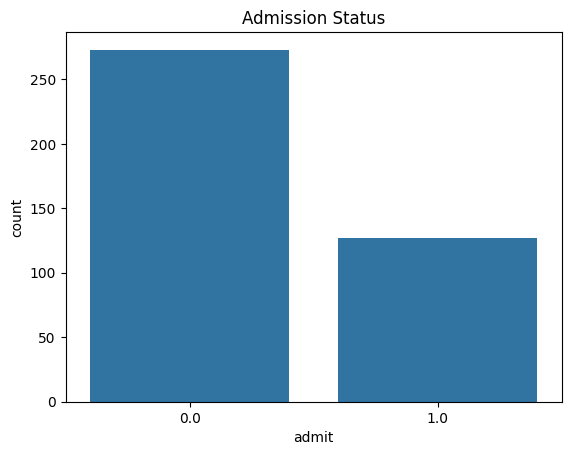

In [8]:
sns.countplot(x='admit', data=df)
plt.title("Admission Status")
plt.show()

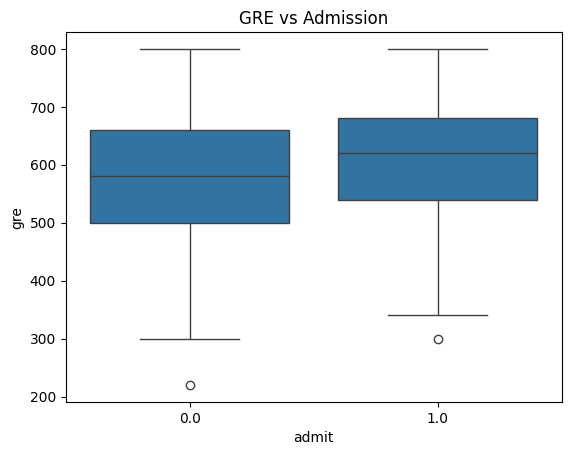

In [9]:
sns.boxplot(x='admit', y='gre', data=df)
plt.title("GRE vs Admission")
plt.show()

In [ ]:
## So the below code connects to statistics and logic behind the logistic regression
## smf.logit() means create an logistic regression model

In [12]:
model = smf.logit(
    'admit ~ gre + gpa + C(rank)',
    data=df
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.573147
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  admit   No. Observations:                  400
Model:                          Logit   Df Residuals:                      394
Method:                           MLE   Df Model:                            5
Date:                Wed, 01 Jul 2026   Pseudo R-squ.:                 0.08292
Time:                        05:41:31   Log-Likelihood:                -229.26
converged:                       True   LL-Null:                       -249.99
Covariance Type:            nonrobust   LLR p-value:                 7.578e-08
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -3.9900      1.140     -3.500      0.000      -6.224      -1.756
C(rank)[T.2.0]   

In [15]:
# Imagine 2 students
# Student A

# GPA = 3.0
# Chance of admission = low

# Student B

# GPA = 4.0
# Chance of admission = higher

# Your logistic regression is trying to answer:

# "How much does the chance of admission change when GPA increases?"

# That's what the Odds Ratio tells us.

# Very Simple Rule
# If Odds Ratio is:

# 1 → no change
# 2 → chances become 2 times higher
# 3 → chances become 3 times higher
# 0.5 → chances become half
# 0.25 → chances become one-fourth
# for my reference to understand the meaning of odd changes

In [16]:
odds_ratios = np.exp(model.params)

print("Odds Ratios:")
print(odds_ratios)

Odds Ratios:
Intercept         0.018500
C(rank)[T.2.0]    0.508931
C(rank)[T.3.0]    0.261792
C(rank)[T.4.0]    0.211938
gre               1.002267
gpa               2.234545
dtype: float64


In [14]:
new_student = pd.DataFrame({
    'gre':[700],
    'gpa':[3.8],
    'rank':[1]
})

probability = model.predict(new_student)

print("Predicted Admission Probability =", probability[0])

Predicted Admission Probability = 0.6571144964005109
